In [283]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif, SequentialFeatureSelector
from functools import partial
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import random as random
import seaborn as sns

# Please do not change these random seeds.
np.random.seed(231)
random.seed(231)
model = KNeighborsClassifier(n_neighbors=5)

In [284]:
# --------------------------- Part 1: Load the Data ---------------------------

data_train = pd.read_csv('Training.csv')
data_train = data_train.rename(columns={'Tryglicerides': 'Triglycerides'})
X_train, y_train = data_train.drop('Status', axis=1), data_train['Status']


data_test = pd.read_csv('Test.csv')
data_test = data_test.rename(columns={'Tryglicerides': 'Triglycerides'})
X_test, y_test = data_test.drop('Status', axis=1), data_test['Status']

print(X_train.head(5))

X_train.info()

              Drug    Age Sex Ascites Hepatomegaly Spiders Edema  Bilirubin  \
0  D-penicillamine  19567   F       N            Y       N     S        2.3   
1          Placebo  17246   F       N            Y       N     N        2.1   
2          Placebo  17874   F       N            Y       N     S        8.7   
3  D-penicillamine  15895   F       Y            Y       Y     S       17.1   
4          Placebo  24650   F       N            Y       N     N        8.0   

   Cholesterol  Albumin  Copper  Alk_Phos    SGOT  Triglycerides  Platelets  \
0        260.0     3.18   231.0   11320.2  105.78           94.0      216.0   
1        262.0     3.48    58.0    2045.0   89.90           84.0      225.0   
2        310.0     3.89   107.0     637.0  117.00          242.0      298.0   
3        674.0     2.53   207.0    2078.0  182.90          598.0      268.0   
4        468.0     2.81   139.0    2009.0  198.40          139.0      233.0   

   Prothrombin  Stage  
0         12.4    3.0  
1 

In [285]:
# --------------------------- Part 1: Data Preprocessing ---------------------------

# Identify numerical and categorical columns

numerical_cols = ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Triglycerides', 'Platelets', 'Prothrombin']  
categorical_cols = ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Stage']

### Step 1: Handle Missing Values ###
# Define and apply appropriate imputers for numerical and categorical features.
# Ensure consistency between X_train and X_test.

from sklearn.impute import SimpleImputer
# Impute numerical features with median
num_imputer = SimpleImputer(strategy='median')
num_imputer.fit(X_train[numerical_cols])
X_train[numerical_cols] = num_imputer.transform(X_train[numerical_cols])
X_test[numerical_cols] = num_imputer.transform(X_test[numerical_cols])

# Impute categorical features with most frequent (mode)
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

### Step 2: Encoding Categorical Features ###
# Convert categorical features into numerical format using encoding techniques.

# Checked for any strong correlations between categorical features using crosstab, but did not find any strong correlations that would warrant dropping any features.
# for col1 in categorical_cols: 
#    for col2 in categorical_cols:
#        print(pd.crosstab(X_train[col1], X_train[col2]))

# Nominal encoding using OneHotEncoder for categorical features
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
categorical_cols = categorical_cols.copy()
categorical_cols.remove('Stage')

train_idx = X_train.index
test_idx = X_test.index

X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoder.get_feature_names_out(categorical_cols), index=train_idx)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoder.get_feature_names_out(categorical_cols), index=test_idx)

X_train_num = X_train.drop(categorical_cols, axis=1)
X_test_num = X_test.drop(categorical_cols, axis=1)

X_train = pd.concat([X_train_num, X_train_encoded], axis=1)
X_test = pd.concat([X_test_num, X_test_encoded], axis=1)

### Step 3: Feature Scaling ###
# Apply scaling/normalization to features.

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_process = scaler.fit_transform(X_train)  # Processed/transformed training set
X_test_process = scaler.transform(X_test)  # Processed/transformed test set

# Train the model using all available features.
model.fit(X_train_process, y_train)
y_pred = model.predict(X_test_process)
print(f"All Features: {balanced_accuracy_score(y_test, y_pred):.4f}")

All Features: 0.6947


In [312]:
# --------------------------- Part 2: Feature Ranking ---------------------------
# Use SelectKBest with mutual_info_classif to select the top 7 features from the processed training set X_train_process.
# You should use mutual_info_fix as the parameter for SelectKBest to ensure random_state is set to 231 for reproducibility.
mutual_info_fix = partial(mutual_info_classif, random_state=231)
selector_kbest = SelectKBest(score_func=mutual_info_fix, k=7)
X_train_kbest = selector_kbest.fit_transform(X_train_process, y_train)
X_test_kbest = selector_kbest.transform(X_test_process)

# Train the model with selected features.
model.fit(X_train_kbest, y_train)
y_pred = model.predict(X_test_kbest)
print(f"Feature Ranking: {balanced_accuracy_score(y_test, y_pred):.4f}")

# Train the model with all features.
model.fit(X_train_process, y_train)
y_pred = model.predict(X_test_process)
print(f"All Features: {balanced_accuracy_score(y_test, y_pred):.4f}")


Feature Ranking: 0.6538
All Features: 0.6947


In [287]:
# Get the mask of selected features
selected_mask = selector_kbest.get_support()

# Get the names of the selected features
selected_features = X_train.columns[selected_mask]
display(selected_features)

Index(['Bilirubin', 'Alk_Phos', 'SGOT', 'Prothrombin', 'Stage', 'Ascites_N',
       'Spiders_N'],
      dtype='object')

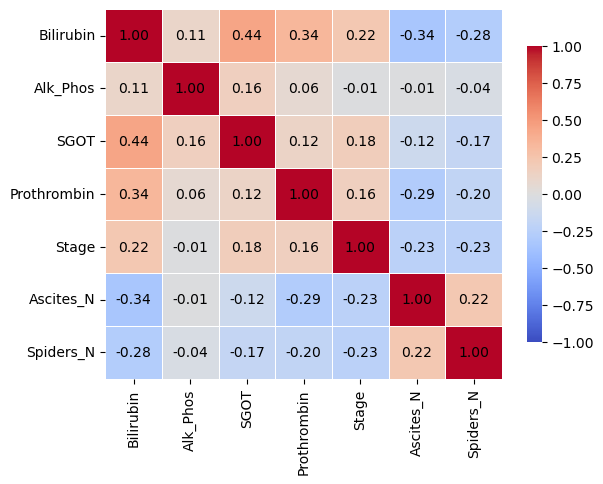

In [ ]:
import matplotlib.pyplot as plt

X_train_sel = X_train[selected_features]
features = selected_features.to_list()
corr = X_train_sel.corr()

ax = sns.heatmap(
    corr, 
    cmap='coolwarm', 
    linewidths=0.5, 
    vmin=-1, vmax=1, 
    cbar_kws={"shrink": 0.8},
    xticklabels=corr.columns,
    yticklabels=corr.index
)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(
            j + 0.5,  # X position
            i + 0.5,  # Y position
            f"{corr.iloc[i, j]:.2f}",  # Text content
            ha='center', 
            va='center', 
            color='black', 
            fontsize=10, 
        )

plt.show()

# Standard heatmap method having issues printing all values, so I manually added text annotations for every cell using solution from 
# https://community.fabric.microsoft.com/t5/Data-Science/seaborn-plot-not-rendering-properly/m-p/4623640#M691
# Updating seaborn version did not resolve

• Evaluate and compare the performance of KNN (K=5) on the test set using
the subset containing the top seven features and the original feature set (after
the data preprocessing steps). Determine which one is better and provide your
justification.
• Use a heatmap to show the Pearson correlation between the top seven features.
In your report, you should show your heatmap, provide an analysis of the
visualisation, and interpret how the features relate to each other.

In [313]:
# --------------------------- Part 3: Sequential Feature Selection ---------------------------
# Use Sequential Backward Selection (SBS) to select a subset of 7 features from the processed training set X_train_process.
selector_sequential = SequentialFeatureSelector(estimator=model, n_features_to_select=7, direction='backward')

X_train_sbfs = selector_sequential.fit_transform(X_train_process, y_train)
X_test_sbfs = selector_sequential.transform(X_test_process)

# Train the model with selected features.
model.fit(X_train_sbfs, y_train)
y_pred = model.predict(X_test_sbfs)
print(f"Sequential Feature Selection: {balanced_accuracy_score(y_test, y_pred):.4f}")

# Train the model with selected features.
model.fit(X_train_kbest, y_train)
y_pred = model.predict(X_test_kbest)
print(f"Feature Ranking: {balanced_accuracy_score(y_test, y_pred):.4f}")

Sequential Feature Selection: 0.6575
Feature Ranking: 0.6538


Use a heatmap to show the Pearson correlation between the seven selected
features. Provide an analysis of the visualisation, interpreting how the
features relate to each other.

In [310]:
# Get the mask of selected features
selected_mask = selector_sequential.get_support()

# Get the names of the selected features
selected_features = X_train.columns[selected_mask]
display(selected_features)

Index(['Age', 'Bilirubin', 'Copper', 'SGOT', 'Prothrombin', 'Drug_Placebo',
       'Ascites_Y'],
      dtype='object')

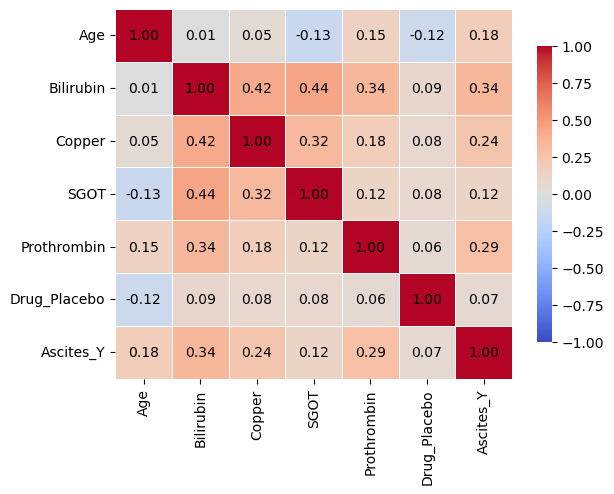

In [311]:
X_train_sel = X_train[selected_features]
features = selected_features.to_list()
corr = X_train_sel.corr()

ax = sns.heatmap(
    corr, 
    cmap='coolwarm', 
    linewidths=0.5, 
    vmin=-1, vmax=1, 
    cbar_kws={"shrink": 0.8},
    xticklabels=corr.columns,
    yticklabels=corr.index
)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(
            j + 0.5,  # X position
            i + 0.5,  # Y position
            f"{corr.iloc[i, j]:.2f}",  # Text content
            ha='center', 
            va='center', 
            color='black', 
            fontsize=10, 
        )

plt.show()

# Standard heatmap method having issues printing all values, so I manually added text annotations for every cell using solution from 
# https://community.fabric.microsoft.com/t5/Data-Science/seaborn-plot-not-rendering-properly/m-p/4623640#M691
# Updating seaborn version did not resolve

In [315]:
cols = ['nFeatures', 'Accuracy']

accuracies = pd.DataFrame(columns=cols)
d = [1, 3, 7, 12, 17]

for i in d:
    selector_sequential = SequentialFeatureSelector(estimator=model, n_features_to_select=i, direction='backward')

    X_train_sbfs = selector_sequential.fit_transform(X_train_process, y_train)
    X_test_sbfs = selector_sequential.transform(X_test_process)

# Train the model with selected features.
    model.fit(X_train_sbfs, y_train)
    y_pred = model.predict(X_test_sbfs)
    print(f"Sequential Feature Selection ({i} features): {balanced_accuracy_score(y_test, y_pred):.4f}")
    accuracies.loc[len(accuracies)] = [i, balanced_accuracy_score(y_test, y_pred)]
print(accuracies)

Sequential Feature Selection (1 features): 0.7488
Sequential Feature Selection (3 features): 0.7019
Sequential Feature Selection (7 features): 0.6575
Sequential Feature Selection (12 features): 0.6635
Sequential Feature Selection (17 features): 0.6406
   nFeatures  Accuracy
0        1.0  0.748798
1        3.0  0.701923
2        7.0  0.657452
3       12.0  0.663462
4       17.0  0.640625


Setting the number of selected features, d, to each of {1, 3, 7, 12, 17} and
obtaining the test accuracy with KNN (K=5) for each case.
• Choose an appropriate visualisation method to demonstrate the relation-
ship between the obtained test accuracy and the corresponding number of
selected features.
• Based on the visualisation, analyse the relationship between test accuracy
and the number of selected features.